In [198]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

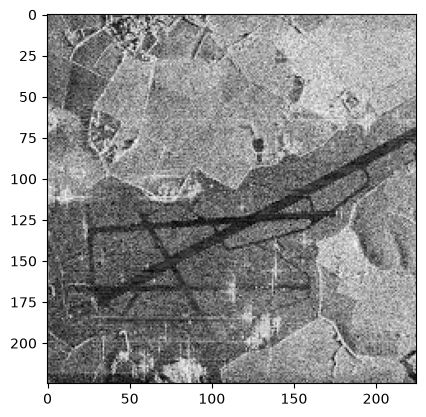

In [199]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap='gray')

1. Для изображения sar_3.jpg найти наиболее протяженный участок (выделить линии при помощи преобразования Хафа)

In [200]:
no_noise = cv2.medianBlur(image_gray, 5)
canny = cv2.Canny(no_noise,50,150,apertureSize = 3)
lines = cv2.HoughLines(canny, 1, np.pi / 180, 100)
print(f"Найдено линий: {len(lines)}")

Найдено линий: 2


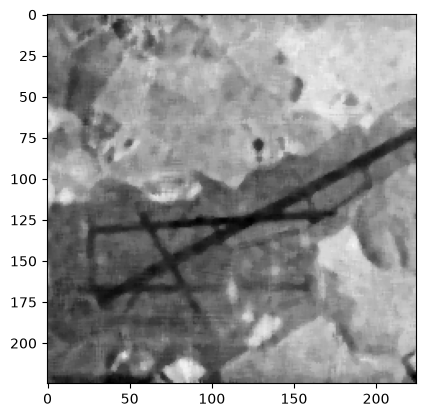

In [201]:
plt.imshow(no_noise, cmap='gray')

In [202]:
import math 

longest_line = None
max_length = 0

if lines is not None:
        for i in range(0, len(lines)):
            rho = lines[i][0][0]
            theta = lines[i][0][1]
            a = math.cos(theta)
            b = math.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            if length > max_length:
                max_length = length
                longest_line = (x1, y1, x2, y2)
lx1, ly1, lx2, ly2 = longest_line
cv2.line(image, (lx1, ly1), (lx2, ly2), (0, 0, 255), 3)

array([[[116, 116, 116],
        [ 59,  59,  59],
        [128, 128, 128],
        ...,
        [187, 187, 187],
        [192, 192, 192],
        [195, 195, 195]],

       [[143, 143, 143],
        [114, 114, 114],
        [ 93,  93,  93],
        ...,
        [198, 198, 198],
        [147, 147, 147],
        [209, 209, 209]],

       [[104, 104, 104],
        [ 96,  96,  96],
        [119, 119, 119],
        ...,
        [169, 169, 169],
        [191, 191, 191],
        [188, 188, 188]],

       ...,

       [[117, 117, 117],
        [ 59,  59,  59],
        [ 85,  85,  85],
        ...,
        [101, 101, 101],
        [ 20,  20,  20],
        [ 23,  23,  23]],

       [[ 88,  88,  88],
        [149, 149, 149],
        [ 64,  64,  64],
        ...,
        [158, 158, 158],
        [102, 102, 102],
        [ 50,  50,  50]],

       [[ 61,  61,  61],
        [110, 110, 110],
        [102, 102, 102],
        ...,
        [146, 146, 146],
        [124, 124, 124],
        [ 53,  53,  53]]

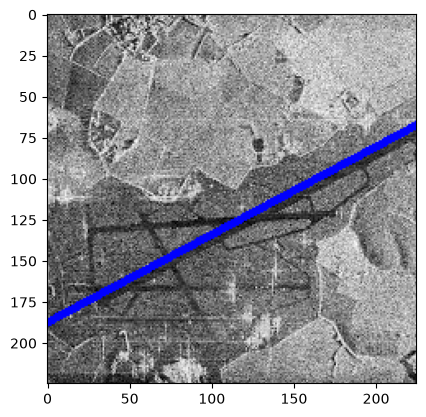

In [203]:
plt.imshow(image)

2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [204]:
#Точечная
import copy

bin_img = copy.deepcopy(image_gray)
T = 75
bin_img[image_gray < T] = 0
bin_img[image_gray >=T] = 255

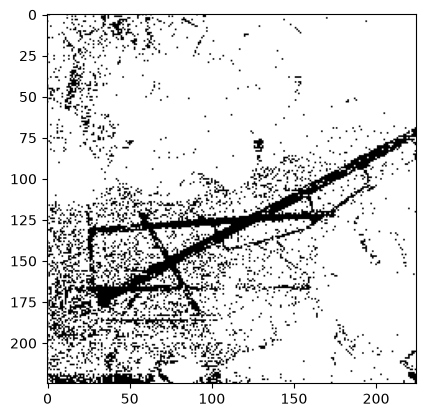

In [205]:
plt.imshow(bin_img, cmap='gray')

In [206]:
#Отсу
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

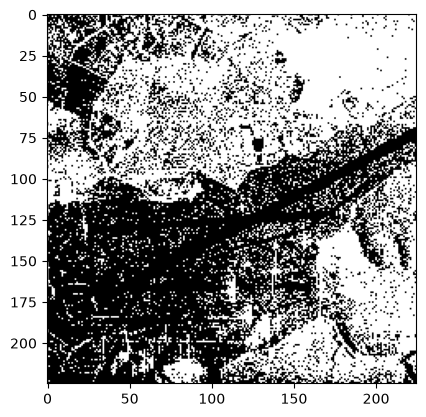

In [207]:
plt.imshow(th2, cmap="gray")

In [208]:
#Адаптивная
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,69,21)

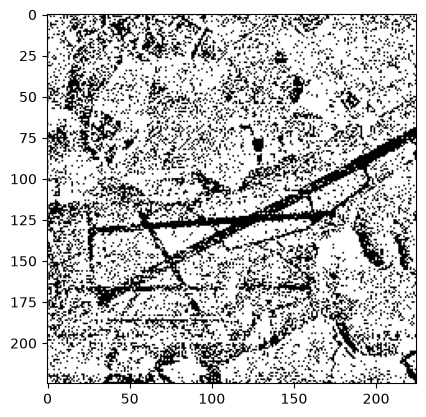

In [209]:
plt.imshow(th3, cmap="gray")

In [210]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [211]:
img = cv2.GaussianBlur(image_gray, (5,5),0)
img = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV,69,21)
contours, _ = cv2.findContours(img,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

In [212]:
for c in contours:
    if cv2.contourArea(c) > 700:
        cv2.drawContours(image,[c],-1,(0, 255, 0),1)

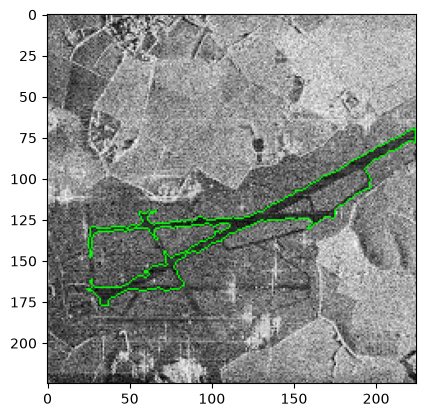

In [213]:
plt.imshow(image)